# Практика к занятию : бэггинг и случайный лес

**Что попробуем**:

1. Загрузим открытый датасет `diabetes` из `sklearn` (задача регрессии).
2. Реализуем простой бэггинг вручную (ансамбль деревьев решений с бутстрэпом).
3. Реализуем 'ручной' случайный лес (т.е. бэггинг + случайная подвыборка признаков для каждого дерева).
4. Сравним наши реализации с `BaggingRegressor` и `RandomForestRegressor` из `sklearn` по метрикам: RMSE, MAE, R2.
5. Оценим важности признаков (feature importances) для каждой модели.

In [ ]:
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
def print_metrics(name, y_true, y_pred):
    # Функция для форматированного вывода метрик
    m = regression_metrics(y_true, y_pred)
    print(f"{name}: RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, R2={m['R2']:.4f}")

def regression_metrics(y_true, y_pred):
    # метрики регрессии
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

In [ ]:
# Загрузка датасета и разделение на train/test
Xy = load_diabetes(as_frame=True)
df = Xy.frame.copy()
X = df.drop(columns=[Xy.target.name])
y = df[Xy.target.name]

In [ ]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [ ]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [ ]:
# Небольшая предобработка: стандартизируем признаки (полезно для визуализации и стабильности)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=28)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (331, 10)
Test size: (111, 10)


In [ ]:
# Базовая модель: одиночное дерево решений
single_tree = DecisionTreeRegressor(random_state=0, min_samples_leaf=20)
single_tree.fit(X_train, y_train)

y_pred_tree_train = single_tree.predict(X_train)
print_metrics('DecisionTree train', y_train, y_pred_tree_train)

y_pred_tree_test = single_tree.predict(X_test)
print_metrics('DecisionTree test', y_test, y_pred_tree_test)

DecisionTree train: RMSE=50.4947, MAE=39.6377, R2=0.5591
DecisionTree test: RMSE=66.7143, MAE=53.9284, R2=0.2990


In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_reg_train = reg.predict(X_train)
print_metrics('LinearRegression train', y_train, y_pred_reg_train)

y_pred_reg_test = reg.predict(X_test)
print_metrics('LinearRegression test', y_test, y_pred_reg_test)

LinearRegression train: RMSE=52.1821, MAE=41.5586, R2=0.5291
LinearRegression test: RMSE=57.8129, MAE=48.3749, R2=0.4736


In [ ]:
X_train.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

In [ ]:
reg.coef_

array([  0.11919378, -10.95787292,  21.95363307,  18.50129689,
       -36.57243021,  18.09272903,   8.91350274,  14.7707773 ,
        34.77028001,   2.77916268])

In [ ]:
y_train.min(), y_train.max()

(25.0, 341.0)

In [ ]:
 73.4643 / (y_train.max() - y_train.min()) * 100

23.24819620253164

## Реализация Bagging вручную

Идея: обучить N деревьев на бутстрэп-выборках (sample with replacement) и усреднить их предсказания.
Здесь используем `DecisionTreeRegressor` без ограничения `max_features` (т.е. все признаки доступны при каждом сплите).

In [ ]:
import random
help(random.randint)

Help on method randint in module random:

randint(a, b) method of random.Random instance
    Return random integer in range [a, b], including both end points.



In [ ]:
def manual_bagging_predict(
    X_train, y_train, X_test,
    n_estimators=50, max_samples=1.0,
    random_state=None
  ):
    # Инициализируем генератор случайных чисел для воспроизводимости
    rng = np.random.RandomState(random_state)

    # Размер обучающей выборки
    n_samples = X_train.shape[0]

    # Размер одной бутстрэп-выборки
    sample_size = int(max_samples * n_samples)

    preds_test = []   # список предсказаний от каждого дерева
    preds_train = []
    trees = []   # список обученных деревьев

    for i in range(n_estimators):
        # Сэмплируем индексы с возвращением (bootstrap)
        inds = rng.randint(0, n_samples, size=sample_size)
        Xt = X_train.iloc[inds]
        yt = y_train.iloc[inds]

        # Создаём и обучаем дерево решений
        tree = DecisionTreeRegressor(random_state=rng.randint(0, 1_000_000))
        tree.fit(Xt, yt)

        trees.append(tree)
        preds_test.append(tree.predict(X_test))
        preds_train.append(tree.predict(X_train))

    # preds имеет форму (число деревьев, число объектов теста)
    preds_train = np.vstack(preds_train)
    preds_test = np.vstack(preds_test)

    # Усредняем предсказания по всем деревьям
    return preds_train.mean(axis=0), preds_test.mean(axis=0), trees

In [ ]:
# обучим и оценим
y_pred_manual_bag_train, y_pred_manual_bag_test, bag_trees = manual_bagging_predict(
    X_train, y_train, X_test,
    n_estimators=300, max_samples=1.0, random_state=0
)

print_metrics('Manual Bagging (50 trees)', y_train, y_pred_manual_bag_train)
print_metrics('Manual Bagging (50 trees)', y_test, y_pred_manual_bag_test)

Manual Bagging (50 trees): RMSE=20.7106, MAE=17.0309, R2=0.9258
Manual Bagging (50 trees): RMSE=62.2419, MAE=50.8110, R2=0.3898


## Ручной Random Forest

Отличие от бэггинга: при построении каждого сплита дерево рассматривает только случайное подмножество признаков (`max_features`).
Мы реализуем это, создавая деревья `DecisionTreeRegressor` с параметром `max_features='sqrt'` (как часто используют для регрессии — sqrt(n_features)).

In [ ]:
# help(DecisionTreeRegressor)

In [ ]:
def manual_random_forest_predict(
    X_train, y_train, X_test,
    n_estimators=50, max_samples=1.0,
    max_features='sqrt', random_state=None
):
    # Инициализация генератора случайных чисел
    rng = np.random.RandomState(random_state)

    # Количество объектов в обучающей выборке
    n_samples = X_train.shape[0]
    # Размер выборки для каждого дерева (bootstrap-сэмпл)
    sample_size = int(max_samples * n_samples)

    preds = []   # список предсказаний от каждого дерева
    trees = []   # список обученных деревьев

    # Строим n_estimators деревьев
    for i in range(n_estimators):
        # Случайный bootstrap-сэмпл из обучающей выборки
        inds = rng.randint(0, n_samples, size=sample_size)
        Xt = X_train.iloc[inds]
        yt = y_train.iloc[inds]

        # Дерево с ограничением по числу признаков (max_features)
        # Это и отличает случайный лес от простого бэггинга
        tree = DecisionTreeRegressor(
            max_features=max_features,
            random_state=rng.randint(0, 1_000_000),
            min_samples_leaf=15
        )

        # Обучение дерева
        tree.fit(Xt, yt)

        # Сохраняем дерево и его предсказания
        trees.append(tree)
        preds.append(tree.predict(X_test))

    # Собираем предсказания всех деревьев в матрицу
    # размерности (n_estimators, n_test)
    preds = np.vstack(preds)

    # Возвращаем среднее предсказание и список деревьев
    return preds.mean(axis=0), trees

In [ ]:
# обучим и оценим
y_pred_manual_rf, rf_trees = manual_random_forest_predict(
    X_train, y_train, X_test,
    n_estimators=200, max_samples=1.0,
    max_features='sqrt', random_state=0
)
print_metrics('Manual Random Forest (50 trees, max_features=sqrt)', y_test, y_pred_manual_rf)

Manual Random Forest (50 trees, max_features=sqrt): RMSE=52.7872, MAE=42.9272, R2=0.4961


## Сравнение с `sklearn` (BaggingRegressor и RandomForestRegressor)

In [ ]:
# sklearn BaggingRegressor
br = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    max_samples=1.0,
    random_state=0
)
br.fit(X_train, y_train)
y_pred_sklearn_bag = br.predict(X_test)
print_metrics('sklearn BaggingRegressor (50 trees)', y_test, y_pred_sklearn_bag)

# sklearn RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=50, max_features='sqrt', random_state=42)
rfr.fit(X_train, y_train)
y_pred_sklearn_rf = rfr.predict(X_test)
print_metrics('sklearn RandomForestRegressor (50 trees, max_features=sqrt)', y_test, y_pred_sklearn_rf)

sklearn BaggingRegressor (50 trees): RMSE=53.6896, MAE=42.6402, R2=0.4787
sklearn RandomForestRegressor (50 trees, max_features=sqrt): RMSE=53.1838, MAE=42.0207, R2=0.4885


In [ ]:
!  pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 7.9 MB/s eta 0:00:00


In [ ]:
# Подбор гиперпараметров для RandomForestRegressor с помощью Optuna

import optuna

def objective(trial):
    # Определяем пространство поиска гиперпараметров
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 1, 32, log=True)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Создаем модель RandomForestRegressor с заданными гиперпараметрами
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1 # Используем все доступные ядра процессора
    )

    # Обучаем модель
    model.fit(X_train, y_train)

    # Предсказываем на тестовой выборке
    y_pred = model.predict(X_test)

    # Вычисляем метрику (например, RMSE)
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    return rmse

# Создаем исследование Optuna
study = optuna.create_study(direction='minimize')

# Запускаем оптимизацию. Можно указать количество испытаний (n_trials)
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры и лучшую метрику
print("Best hyperparameters: ", study.best_params)
print("Best RMSE: ", study.best_value)

# Обучаем финальную модель с лучшими гиперпараметрами
best_rfr = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_rfr.fit(X_train, y_train)
y_pred_best_rfr = best_rfr.predict(X_test)

# Оцениваем финальную модель на тестовой выборке
print_metrics('sklearn RandomForestRegressor (tuned)', y_test, y_pred_best_rfr)

[I 2025-11-01 15:13:34,425] A new study created in memory with name: no-name-84323435-222e-470b-94ea-9ca1502f5e91
[I 2025-11-01 15:13:35,257] Trial 0 finished with value: 60.23516416402539 and parameters: {'n_estimators': 303, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 60.23516416402539.
[I 2025-11-01 15:13:35,789] Trial 1 finished with value: 62.43811695967977 and parameters: {'n_estimators': 196, 'max_depth': 2, 'min_samples_split': 7, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: 60.23516416402539.
[I 2025-11-01 15:13:35,965] Trial 2 finished with value: 61.29856048893745 and parameters: {'n_estimators': 60, 'max_depth': 32, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 60.23516416402539.
[I 2025-11-01 15:13:36,139] Trial 3 finished with value: 65.04278343365189 and parameters: {'n_estimators': 57, 'max_depth': 1, 'min_samples_

Best hyperparameters:  {'n_estimators': 202, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 14, 'max_features': None}
Best RMSE:  59.57562934776548
sklearn RandomForestRegressor (tuned): RMSE=59.5756, MAE=49.0523, R2=0.4410


In [ ]:
# Соберём все метрики в таблицу для наглядного сравнения
results = []
models = [
    ('DecisionTree', y_pred_tree_test),
    ('Manual Bagging', y_pred_manual_bag_test),
    ('Manual RandomForest', y_pred_manual_rf),
    ('sklearn Bagging', y_pred_sklearn_bag),
    ('sklearn RandomForest', y_pred_sklearn_rf),
]
for name, pred in models:
    m = regression_metrics(y_test, pred)
    results.append({'model': name, **m})
res_df = pd.DataFrame(results).set_index('model')
res_df

,RMSE,MAE,R2
model,,,
DecisionTree,66.714321,53.928441,0.298977
Manual Bagging,62.241909,50.811021,0.389818
Manual RandomForest,85.316898,69.869356,-0.146473
sklearn Bagging,89.077836,71.679459,-0.249779
sklearn RandomForest,85.744349,69.420721,-0.157990


## Важности признаков (feature importances)

Для ансамблей усредним важности по отдельным деревьям: mean(feature_importances_).
Сравним: manual bagging, manual rf, sklearn rf.

In [ ]:
# Важности для manual bagging
importances_bag = np.mean([t.feature_importances_ for t in bag_trees], axis=0)
importances_mrf = np.mean([t.feature_importances_ for t in rf_trees], axis=0)
importances_sklearn_rf = rfr.feature_importances_

feat_names = X_train.columns.tolist()
fi_df = pd.DataFrame({
    'feature': feat_names,
    'manual_bagging': importances_bag,
    'manual_random_forest': importances_mrf,
    'sklearn_random_forest': importances_sklearn_rf
}).set_index('feature')
fi_df_sorted = fi_df.sort_values('sklearn_random_forest', ascending=True)
fi_df_sorted

,manual_bagging,manual_random_forest,sklearn_random_forest
feature,,,
sex,0.011864,0.012074,0.012202
age,0.062400,0.058228,0.063522
s2,0.056499,0.069974,0.065698
s1,0.046145,0.067314,0.071821
s4,0.026447,0.061401,0.073612
s6,0.066535,0.068901,0.083308
s3,0.052119,0.099975,0.084071
bp,0.104404,0.134455,0.117932
s5,0.214500,0.175807,0.171237


<Axes: >

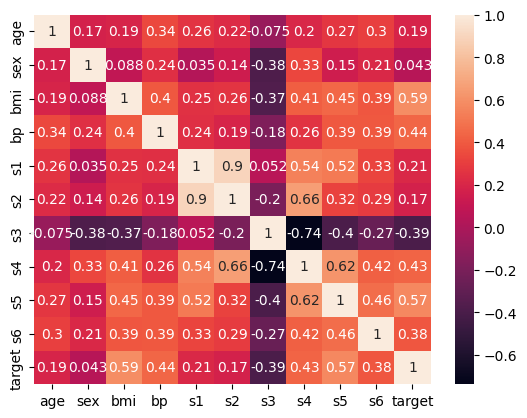

In [ ]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)

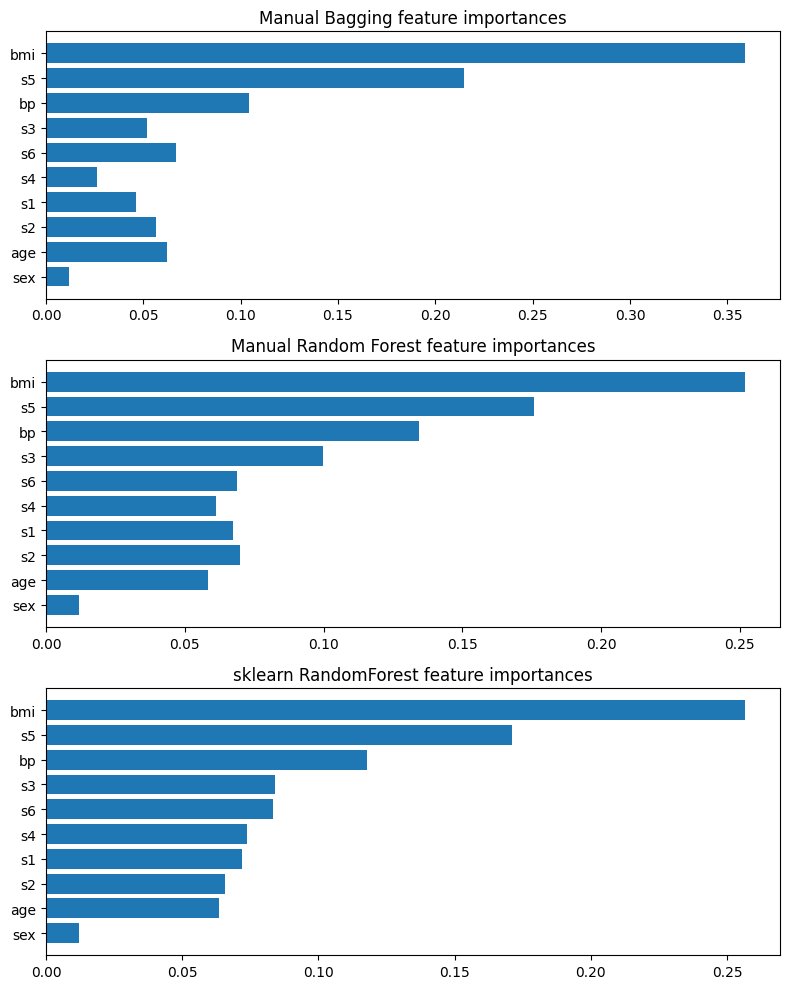

In [ ]:
# Построим горизонтальные столбчатые графики важности признаков по моделям
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 10))

axs[0].barh(fi_df_sorted.index, fi_df_sorted['manual_bagging'])
axs[0].set_title('Manual Bagging feature importances')

axs[1].barh(fi_df_sorted.index, fi_df_sorted['manual_random_forest'])
axs[1].set_title('Manual Random Forest feature importances')

axs[2].barh(fi_df_sorted.index, fi_df_sorted['sklearn_random_forest'])
axs[2].set_title('sklearn RandomForest feature importances')

plt.tight_layout()
plt.show()